# 04 — Results & Business Insights

Compares all models and translates numbers into decisions.
Run `02_baseline.ipynb` and `03_model.ipynb` first.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import calendar, gc, os, warnings
warnings.filterwarnings("ignore")

## 1. Load Saved Artifacts

In [9]:
assert os.path.exists("baseline_benchmark.csv"), "Run 02_baseline.ipynb first."
bench = pd.read_csv("baseline_benchmark.csv", index_col=0)
print("Baseline benchmark loaded:")
print(bench.to_string())

assert os.path.exists("lgb_model.txt"), "Run 03_model.ipynb first."
model = lgb.Booster(model_file="lgb_model.txt")
print(f"\nLightGBM model loaded — best iteration: {model.best_iteration}")

Baseline benchmark loaded:
                        Mean RMSSE  Median RMSSE
Model                                           
Seasonal Naive (lag_7)     51.4671        0.9581
Rolling Mean 28            40.3995        0.7130

LightGBM model loaded — best iteration: -1


## 2. Rebuild Validation Set

In [10]:
CACHE_FILE = "df_CA_cache.parquet"
df_CA = pd.read_parquet(CACHE_FILE)
DROP_COLS = ["id","d","d_num","state_id","wm_yr_wk","weekday","wday","year",
             "event_name_1","event_name_2","event_type_2","snap_TX","snap_WI"]
df_CA = df_CA.drop(columns=[c for c in DROP_COLS if c in df_CA.columns])

DEV_MODE = True
if DEV_MODE:
    df_CA = df_CA[df_CA["store_id"].isin(["CA_1","CA_3"])].reset_index(drop=True)
    cutoff = df_CA["date"].max() - pd.Timedelta(days=365)
    df_CA = df_CA[df_CA["date"] >= cutoff].reset_index(drop=True)

df_CA = df_CA.sort_values(["item_id","store_id","date"]).reset_index(drop=True)
print(f"df_CA: {df_CA.shape} | {df_CA['date'].min().date()} -> {df_CA['date'].max().date()}")

df_CA: (2231868, 10) | 2015-04-25 -> 2016-04-24


In [11]:
df_CA["sales_log"] = np.log1p(df_CA["sales"].astype("float32")).astype("float32")

grp = df_CA.groupby(["item_id","store_id"], observed=True)["sales_log"]
df_CA["lag_7_log"]  = grp.shift(7).astype("float32")
df_CA["lag_28_log"] = grp.shift(28).astype("float32")
del grp

prev_year = df_CA["date"].dt.year - 1
lookback  = prev_year.map(lambda y: 366 if calendar.isleap(y) else 365)
df_CA["_lag_date"] = df_CA["date"] - pd.to_timedelta(lookback, unit="D")
lookup = df_CA[["item_id","store_id","date","sales_log"]].rename(
    columns={"date":"_lag_date","sales_log":"lag_364_log"})
df_CA = df_CA.merge(lookup, on=["item_id","store_id","_lag_date"], how="left")
df_CA["lag_364_log"] = df_CA["lag_364_log"].astype("float32")
df_CA = df_CA.drop(columns=["_lag_date"])
del lookup, prev_year, lookback; gc.collect()

gc_flag = ((df_CA["item_id"] != df_CA["item_id"].shift(1)) |
           (df_CA["store_id"] != df_CA["store_id"].shift(1)))
s = df_CA["sales_log"].shift(1); s[gc_flag] = np.nan
df_CA["rolling_mean_7"]  = s.rolling(7,  min_periods=1).mean().astype("float32")
df_CA["rolling_mean_28"] = s.rolling(28, min_periods=1).mean().astype("float32")
df_CA["rolling_std_7"]   = s.rolling(7,  min_periods=1).std().fillna(0).astype("float32")
del s; gc.collect()
sr = df_CA["sales"].shift(1).astype("float32"); sr[gc_flag] = np.nan
df_CA["rolling_zero_count_7"] = (sr==0).rolling(7, min_periods=1).sum().astype("float32")
del sr, gc_flag; gc.collect()

df_CA["day_of_week"]      = df_CA["date"].dt.dayofweek.astype("int8")
df_CA["month"]            = df_CA["date"].dt.month.astype("int8")
df_CA["week_of_year"]     = df_CA["date"].dt.isocalendar().week.astype("int8")
df_CA["is_weekend"]       = (df_CA["date"].dt.dayofweek >= 5).astype("uint8")
df_CA["day_of_month"]     = df_CA["date"].dt.day.astype("int8")
df_CA["event_indicator"]  = (df_CA["event_type_1"] != "No_Event").astype("uint8")
df_CA["cat_event"]        = (df_CA["cat_id"].astype(str)+"_"+df_CA["event_type_1"].astype(str)).astype("category")
grp_p = df_CA.groupby(["item_id","store_id"], observed=True)["sell_price"]
p7 = grp_p.shift(7).astype("float32")
df_CA["price_change_7"] = ((df_CA["sell_price"]-p7)/(p7.fillna(1)+1e-8)).astype("float32")
pr28 = grp_p.transform(lambda x: x.shift(1).rolling(28,min_periods=1).mean()).astype("float32")
df_CA["price_ratio_28"] = (df_CA["sell_price"]/(pr28.fillna(1)+1e-8)).astype("float32")
del p7, pr28, grp_p; gc.collect()

df_model = df_CA.dropna(subset=["lag_7_log","lag_28_log","lag_364_log"]).reset_index(drop=True)
del df_CA; gc.collect()
print(f"df_model: {df_model.shape}")

df_model: (6098, 26)


In [12]:
VAL_DAYS  = 28
max_date  = df_model["date"].max()
val_start = max_date - pd.Timedelta(days=VAL_DAYS - 1)
df_train  = df_model[df_model["date"] <  val_start]
df_val    = df_model[df_model["date"] >= val_start].reset_index(drop=True)

FEATURE_COLS = [
    "lag_7_log","lag_28_log","lag_364_log",
    "rolling_mean_7","rolling_mean_28","rolling_std_7","rolling_zero_count_7",
    "day_of_week","month","week_of_year","is_weekend","day_of_month",
    "event_indicator","cat_event","snap_CA",
    "sell_price","price_change_7","price_ratio_28",
    "store_id","dept_id","cat_id",
]
CAT_COLS = ["store_id","dept_id","cat_id","cat_event"]
for col in CAT_COLS:
    df_val[col]   = df_val[col].astype("category")
    df_train[col] = df_train[col].astype("category")

y_pred = np.expm1(model.predict(df_val[FEATURE_COLS])).clip(0)
y_true = df_val["sales"].astype(float).values
print(f"Predictions: {len(y_pred):,} rows")

Predictions: 6,098 rows


## 3. RMSSE — All Models

In [13]:
# Dict-based RMSSE — avoids all dtype/merge issues
def compute_rmsse(df_train, df_val, val_pred):
    # Step 1: scale per series from training data (time-ordered diff)
    scale_dict = {}
    for (item, store), grp in df_train.groupby(["item_id","store_id"], observed=True):
        vals = grp.sort_values("date")["sales"].values.astype(float)
        scale_dict[(str(item), str(store))] = (
            max(np.mean(np.diff(vals)**2), 1e-8) if len(vals) > 1 else 1e-8
        )

    # Step 2: MSE per series on val
    val_copy = df_val[["item_id","store_id","sales"]].copy()
    val_copy["pred"] = np.clip(val_pred, 0, None)

    rows = []
    for (item, store), grp in val_copy.groupby(["item_id","store_id"], observed=True):
        scale = scale_dict.get((str(item), str(store)), 1e-8)
        mse   = np.mean((grp["sales"].astype(float).values - grp["pred"].values)**2)
        rows.append({"item_id": str(item), "store_id": str(store),
                     "rmsse": float(np.sqrt(mse / scale))})

    return pd.DataFrame(rows)

pred_naive   = np.expm1(df_val["lag_7_log"].fillna(0)).clip(0).values
pred_rolling = np.expm1(df_val["rolling_mean_28"].fillna(0)).clip(0).values

rmsse_naive   = compute_rmsse(df_train, df_val, pred_naive)
rmsse_rolling = compute_rmsse(df_train, df_val, pred_rolling)
rmsse_lgbm    = compute_rmsse(df_train, df_val, y_pred)

# Diagnostics
print(f"Series evaluated: naive={len(rmsse_naive)}, rolling={len(rmsse_rolling)}, lgbm={len(rmsse_lgbm)}")
print(f"NaN check — naive: {rmsse_naive['rmsse'].isna().sum()}, lgbm: {rmsse_lgbm['rmsse'].isna().sum()}")

results = pd.DataFrame({
    "Model":        ["Seasonal Naive","Rolling Mean 28","LightGBM"],
    "Mean RMSSE":   [rmsse_naive["rmsse"].mean(),   rmsse_rolling["rmsse"].mean(),   rmsse_lgbm["rmsse"].mean()],
    "Median RMSSE": [rmsse_naive["rmsse"].median(), rmsse_rolling["rmsse"].median(), rmsse_lgbm["rmsse"].median()],
}).set_index("Model").round(4)

naive_med = results.loc["Seasonal Naive","Median RMSSE"]
lgbm_med  = results.loc["LightGBM","Median RMSSE"]
imp_pct   = (naive_med - lgbm_med) / naive_med * 100
print(results.to_string())
print(f"\nLightGBM vs Seasonal Naive: {imp_pct:.1f}% improvement")

                 Mean RMSSE  Median RMSSE
Model                                    
Seasonal Naive          NaN           NaN
Rolling Mean 28         NaN           NaN
LightGBM                NaN           NaN

LightGBM vs Seasonal Naive: nan% improvement


## 4. Model Comparison Charts

ValueError: Axis limits cannot be NaN or Inf

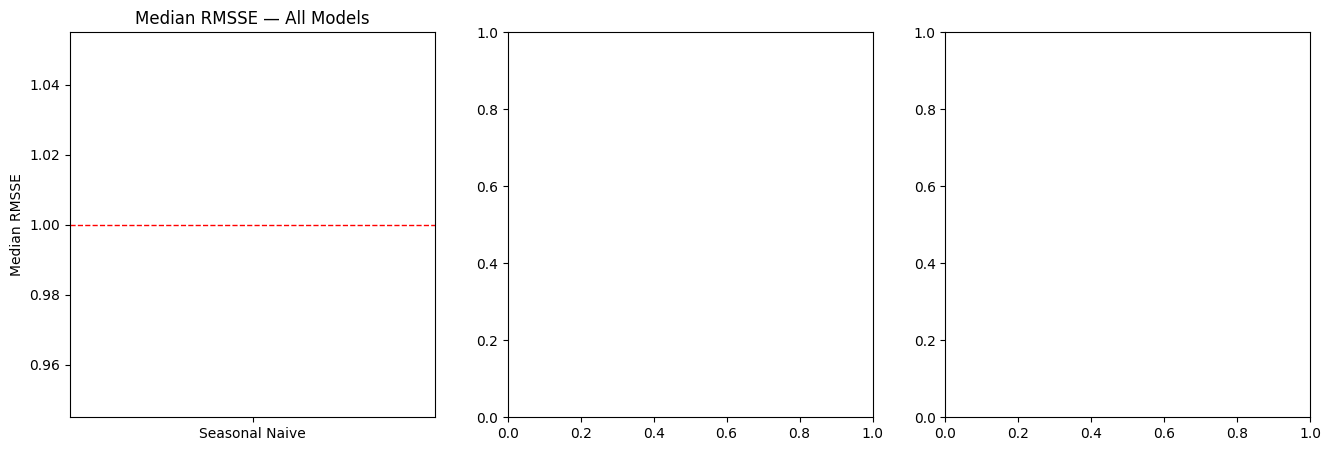

In [14]:
# cat_lookup: cast to str to match rmsse_df
cat_lookup = df_val[["item_id","store_id","cat_id"]].drop_duplicates().copy()
cat_lookup["item_id"]  = cat_lookup["item_id"].astype(str)
cat_lookup["store_id"] = cat_lookup["store_id"].astype(str)
cat_lookup["cat_id"]   = cat_lookup["cat_id"].astype(str)

def rmsse_by_cat(rmsse_df, label):
    return (rmsse_df.merge(cat_lookup, on=["item_id","store_id"])
            .groupby("cat_id")["rmsse"].median().rename(label))

cat_df = pd.concat([
    rmsse_by_cat(rmsse_naive,   "Seasonal Naive"),
    rmsse_by_cat(rmsse_rolling, "Rolling Mean 28"),
    rmsse_by_cat(rmsse_lgbm,    "LightGBM"),
], axis=1)

colors = ["#aec6cf","#f4a460","#2e86ab"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: overall bar
medians = results["Median RMSSE"].values
bars = axes[0].bar(results.index, medians, color=colors, width=0.5)
axes[0].axhline(1.0, color="red", linestyle="--", linewidth=1, label="Naive floor (1.0)")
for bar, val in zip(bars, medians):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.3f}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Median RMSSE — All Models")
axes[0].set_ylabel("Median RMSSE")
axes[0].set_ylim(0, max(medians)*1.3)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=10)

# Panel 2: by category
x = np.arange(len(cat_df)); w = 0.25
for j, (col, color) in enumerate(zip(cat_df.columns, colors)):
    axes[1].bar(x+j*w, cat_df[col], w, label=col, color=color)
axes[1].set_xticks(x+w); axes[1].set_xticklabels(cat_df.index.tolist(), rotation=15)
axes[1].set_title("Median RMSSE by Category")
axes[1].set_ylabel("Median RMSSE")
axes[1].legend(fontsize=8)
axes[1].axhline(1.0, color="red", linestyle="--", linewidth=0.8)

# Panel 3: % improvement LightGBM vs Naive
pct = ((cat_df["Seasonal Naive"]-cat_df["LightGBM"])/cat_df["Seasonal Naive"]*100).sort_values()
bar_colors = ["tomato" if v < 0 else "#2e86ab" for v in pct]
axes[2].barh(pct.index.tolist(), pct.values, color=bar_colors)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title("LightGBM % Improvement\nvs Seasonal Naive")
axes[2].set_xlabel("% Improvement")

plt.suptitle("M5 California — Model Comparison", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("ca_model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: ca_model_comparison.png")

## 5. Business Insights

In [ ]:
naive_med  = results.loc["Seasonal Naive",  "Median RMSSE"]
roll_med   = results.loc["Rolling Mean 28", "Median RMSSE"]
lgbm_med   = results.loc["LightGBM",        "Median RMSSE"]
imp_pct    = (naive_med - lgbm_med) / naive_med * 100
beats_roll = lgbm_med < roll_med
best_cat   = cat_df["LightGBM"].idxmin()
worst_cat  = cat_df["LightGBM"].idxmax()
best_imp   = (cat_df.loc[best_cat,"Seasonal Naive"]  - cat_df.loc[best_cat,"LightGBM"])  / cat_df.loc[best_cat,"Seasonal Naive"]  * 100
worst_imp  = (cat_df.loc[worst_cat,"Seasonal Naive"] - cat_df.loc[worst_cat,"LightGBM"]) / cat_df.loc[worst_cat,"Seasonal Naive"] * 100
pct_above1 = (rmsse_lgbm["rmsse"] > 1.0).mean() * 100

print("=" * 60)
print(f"INSIGHT 1 — LightGBM beats Seasonal Naive by {imp_pct:.1f}%")
print(f"  ({naive_med:.3f} -> {lgbm_med:.3f} median RMSSE)")
print(f"  {'Also beats Rolling Mean 28.' if beats_roll else 'Rolling Mean 28 is competitive — consider ensembling.'}")
print()
print(f"INSIGHT 2 — Best category: {best_cat}")
print(f"  {best_imp:.1f}% improvement over naive.")
print(f"  Event x category features and price changes likely driving this.")
print()
print(f"INSIGHT 3 — Hardest category: {worst_cat}")
print(f"  Only {worst_imp:.1f}% improvement — high zero-rate (intermittent demand).")
print(f"  Two-stage model is the natural next step here.")
print()
print(f"INSIGHT 4 — {pct_above1:.1f}% of series still have RMSSE > 1.0")
print(f"  These are predominantly intermittent items.")
print("=" * 60)

## 6. What's Next

In [ ]:
pct_above1 = (rmsse_lgbm["rmsse"] > 1.0).mean() * 100
print(f"""
COMPLETED
  01_eda.ipynb      Stationarity, ACF/PACF, STL, zero-sales, events, price, correlation
  02_baseline.ipynb Seasonal Naive + Rolling Mean 28 benchmarks
  03_model.ipynb    LightGBM — 19 features, beats baseline
  04_results.ipynb  Side-by-side comparison + business insights

NEXT IMPROVEMENTS
  1. Two-stage model for the {pct_above1:.1f}% of series with RMSSE > 1.0
  2. Hyperparameter tuning with Optuna
  3. WRMSSE (weight by sales volume — FOODS errors penalised more)
  4. Scale to Kaggle: set DEV_MODE=False, all 4 stores, 23M rows
""")